## Publication review notice / Catatan review publikasi

This notebook retains previously executed outputs; it has not been rerun for this publication.
FIRMS dates use UTC, while the cached NASA POWER header uses LST. Matching date labels
does not align daily time windows. Weather correlations, lag analysis and weather panels
are PRE-ALIGNMENT EXPERIMENTS, not final PRD evidence. The regional weather mean also
uses a bounding box without a five-province land mask. Recompute after alignment and
spatial-domain review before interpreting these results.

Output lama belum dihitung ulang. Jangan kutip korelasi cuaca sebagai fakta PRD.
Skor prioritas tidak memakai cuaca atau sekolah; bobotnya tetap provisional.
Median sekolah 2,94 km dihitung atas baris grid-hari (jarak grid diulang pada tiap
tanggal aktif), bukan sekali per grid unik. Kedekatan bukan bukti dampak.
Dashboard adalah rancangan historis, bukan feed live atau alat operasional.
Read ../REVIEW_STATUS.md for the publication limitations.


# FIRELINE — Pipeline Prioritas Verifikasi MVP

Notebook ini menyatukan hasil EDA utama dan dataset pendukung menjadi satu tabel
operasional berbasis grid_id + date.

**Tujuan MVP:** membantu operator melihat area yang perlu diperiksa lebih dahulu.
Skor yang dihasilkan adalah heuristik prioritas sinyal, bukan probabilitas kebakaran,
bukan prediksi, dan bukan instruksi otomatis untuk tindakan lapangan.

In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import requests
import matplotlib.pyplot as plt
from matplotlib import patches
from matplotlib.gridspec import GridSpec
import seaborn as sns
from sklearn.neighbors import BallTree

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")

ROOT = Path.cwd()
for candidate in [Path.cwd(), Path.cwd().parent]:
    if (candidate / "fireline_hotspot_kalimantan_viirs_noaa20_2024_2026.csv").exists():
        ROOT = candidate
        break

FIRMS_PATH = ROOT / "fireline_hotspot_kalimantan_viirs_noaa20_2024_2026.csv"
SCHOOL_PATH = ROOT / "data" / "external" / "schools" / "complete_data.csv"
WEATHER_PATH = ROOT / "outputs" / "external_validation" / "nasa_power_grid_daily.csv"
BIG_CACHE = ROOT / "data" / "external" / "raw" / "big" / "kalimantan_provinces.geojson"
OUTPUT_DIR = ROOT / "mvp_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
BIG_CACHE.parent.mkdir(parents=True, exist_ok=True)

for required in [FIRMS_PATH, SCHOOL_PATH, WEATHER_PATH]:
    assert required.exists(), f"File belum tersedia: {required}"

print("Project root:", ROOT)
print("Output:", OUTPUT_DIR)

Project root: E:\DSA-FINAL\checkpoint_2\Fireline-eda-kaka
Output: E:\DSA-FINAL\checkpoint_2\Fireline-eda-kaka\mvp_outputs


## 1. Ambil batas provinsi resmi BIG

GeoJSON lama pada EDA awal hanya memiliki empat provinsi Kalimantan dan belum
memisahkan Kalimantan Utara. Pipeline MVP memakai layanan peta Badan Informasi
Geospasial yang memuat kode 61 sampai 65. File mentah disimpan sebagai cache lokal.

In [2]:
BIG_QUERY_URL = (
    "https://geoservices.big.go.id/gis/rest/services/"
    "STIG/Batas_Provinsi/MapServer/0/query"
)

if not BIG_CACHE.exists():
    params = {
        "where": "KDPPUM IN ('61','62','63','64','65')",
        "outFields": "KDPPUM,WADMPR",
        "returnGeometry": "true",
        "returnZ": "false",
        "returnM": "false",
        "outSR": "4326",
        "maxAllowableOffset": "0.01",
        "geometryPrecision": "4",
        "f": "geojson",
    }
    response = requests.get(BIG_QUERY_URL, params=params, timeout=180)
    response.raise_for_status()
    BIG_CACHE.write_bytes(response.content)

boundaries = gpd.read_file(BIG_CACHE).to_crs(4326)
boundaries["geometry"] = boundaries.geometry.make_valid()
assert set(["61", "62", "63", "64", "65"]).issubset(
    set(boundaries["KDPPUM"].astype(str))
)
display(boundaries[["KDPPUM", "WADMPR"]].sort_values("KDPPUM"))

E:\DSA-FINAL\.venv\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: OGRGeoJSONReadRawPoint(): too many members in array '[ 110.20399999999999, -3.0646, 0.0, null ]': 4. At most 3 are handled. Ignoring extra members. Further messages of this type will be suppressed.
  return ogr_read(


,KDPPUM,WADMPR
0,61,Kalimantan Barat
1,62,Kalimantan Tengah
2,63,Kalimantan Selatan
3,64,Kalimantan Timur
4,65,Kalimantan Utara


## 2. Audit sumber dan pembersihan minimal

Setiap dataset diberi peran yang berbeda. FIRMS menentukan sinyal utama; sumber
lain hanya menambah label wilayah dan konteks. Tidak ada baris FIRMS yang dibuang
memakai bounding box sempit.

In [3]:
firms_raw = pd.read_csv(FIRMS_PATH)
schools_raw = pd.read_csv(SCHOOL_PATH)
weather_raw = pd.read_csv(WEATHER_PATH, parse_dates=["date"])

firms = firms_raw.copy()
firms["date"] = pd.to_datetime(firms["acq_date"], errors="coerce")
for column in ["latitude", "longitude", "frp", "brightness", "bright_t31"]:
    firms[column] = pd.to_numeric(firms[column], errors="coerce")
firms["confidence"] = firms["confidence"].astype(str).str.lower().str.strip()
firms["daynight"] = firms["daynight"].astype(str).str.upper().str.strip()

valid_mask = (
    firms["date"].notna()
    & firms["latitude"].between(-90, 90)
    & firms["longitude"].between(-180, 180)
    & firms["frp"].ge(0)
)
invalid_rows = int((~valid_mask).sum())
firms = firms.loc[valid_mask].copy()

dataset_audit = pd.DataFrame([
    {
        "dataset": "NASA FIRMS VIIRS NOAA-20",
        "role": "primary",
        "rows": len(firms_raw),
        "status": "used",
        "limitation": "anomali panas satelit, bukan kebakaran terverifikasi",
    },
    {
        "dataset": "NASA POWER Daily",
        "role": "weather context",
        "rows": len(weather_raw),
        "status": "used outside score",
        "limitation": "resolusi lebih kasar dan masih eksploratif",
    },
    {
        "dataset": "Indonesia School Dataset",
        "role": "facility context",
        "rows": len(schools_raw),
        "status": "used outside score",
        "limitation": "kedekatan tidak membuktikan dampak",
    },
    {
        "dataset": "BIG Province Boundary",
        "role": "official province label",
        "rows": len(boundaries),
        "status": "used",
        "limitation": "geometri disederhanakan untuk analisis MVP",
    },
])
display(dataset_audit)
print("Invalid FIRMS rows:", invalid_rows)
print("FIRMS rows used:", len(firms))

,dataset,role,rows,status,limitation
0,NASA FIRMS VIIRS NOAA-20,primary,61583,used,"anomali panas satelit, bukan kebakaran terveri..."
1,NASA POWER Daily,weather context,228798,used outside score,resolusi lebih kasar dan masih eksploratif
2,Indonesia School Dataset,facility context,215371,used outside score,kedekatan tidak membuktikan dampak
3,BIG Province Boundary,official province label,5,used,geometri disederhanakan untuk analisis MVP


Invalid FIRMS rows: 0
FIRMS rows used: 61583


## 3. Bentuk unit grid-hari dan fitur sinyal

Grid 0,1 derajat dipakai sebagai unit agregasi produk. Beberapa observasi satelit
yang berdekatan pada hari yang sama menjadi satu baris antrean. Fitur tujuh hari
dihitung dari aktivitas sebelumnya pada grid yang sama.

In [4]:
GRID_DEG = 0.1
firms["lat_grid"] = (np.floor(firms["latitude"] / GRID_DEG) * GRID_DEG).round(1)
firms["lon_grid"] = (np.floor(firms["longitude"] / GRID_DEG) * GRID_DEG).round(1)
firms["grid_id"] = (
    firms["lat_grid"].map(lambda value: f"{value:.1f}")
    + "_"
    + firms["lon_grid"].map(lambda value: f"{value:.1f}")
)
firms["is_high_conf"] = firms["confidence"].eq("h").astype(int)
firms["is_low_conf"] = firms["confidence"].eq("l").astype(int)
firms["is_nominal_or_high"] = firms["confidence"].isin(["n", "h"]).astype(int)
firms["is_night"] = firms["daynight"].eq("N").astype(int)

grid_date = firms.groupby(
    ["grid_id", "lat_grid", "lon_grid", "date"], as_index=False
).agg(
    detection_count=("grid_id", "size"),
    frp_median_mw=("frp", "median"),
    frp_max_mw=("frp", "max"),
    high_conf_share=("is_high_conf", "mean"),
    low_conf_share=("is_low_conf", "mean"),
    nominal_or_high_share=("is_nominal_or_high", "mean"),
    night_share=("is_night", "mean"),
)


def add_rolling_features(group):
    group = group.sort_values("date").copy()
    indexed = group.set_index("date")
    group["detections_7d"] = (
        indexed["detection_count"].rolling("7D").sum().to_numpy()
    )
    group["active_days_7d"] = (
        indexed["detection_count"].rolling("7D").count().to_numpy()
    )
    return group


grid_date = (
    grid_date.groupby("grid_id", group_keys=False)
    .apply(add_rolling_features)
    .reset_index(drop=True)
)
grid_date["grid_center_lat"] = grid_date["lat_grid"] + GRID_DEG / 2
grid_date["grid_center_lon"] = grid_date["lon_grid"] + GRID_DEG / 2

assert not grid_date.duplicated(["grid_id", "date"]).any()
print("Unique grids:", f"{grid_date['grid_id'].nunique():,}")
print("Grid-date rows:", f"{len(grid_date):,}")
display(grid_date.head())

Unique grids: 2,954
Grid-date rows: 27,411


,grid_id,lat_grid,lon_grid,date,detection_count,frp_median_mw,frp_max_mw,high_conf_share,low_conf_share,nominal_or_high_share,night_share,detections_7d,active_days_7d,grid_center_lat,grid_center_lon
0,-0.1_109.1,-0.1,109.1,2024-09-02,1,2.290,2.29,0.0,0.00,1.00,0.00,1.0,1.0,-0.05,109.15
1,-0.1_109.2,-0.1,109.2,2024-09-22,1,3.460,3.46,0.0,0.00,1.00,0.00,1.0,1.0,-0.05,109.25
2,-0.1_109.3,-0.1,109.3,2024-09-16,1,15.760,15.76,0.0,0.00,1.00,0.00,1.0,1.0,-0.05,109.35
3,-0.1_109.3,-0.1,109.3,2024-09-17,2,4.815,5.72,0.0,0.00,1.00,0.00,3.0,2.0,-0.05,109.35
4,-0.1_109.3,-0.1,109.3,2024-10-29,4,7.140,8.65,0.0,0.25,0.75,0.25,4.0,1.0,-0.05,109.35


## 4. Tambahkan provinsi, sekolah, dan cuaca sebagai konteks

Jarak sekolah dan cuaca tidak digunakan dalam skor prioritas saat ini. Pemisahan
ini mencegah konteks eksternal yang belum tervalidasi mengubah urutan secara diam-diam.

In [5]:
schools = schools_raw.copy()
schools["lat"] = pd.to_numeric(schools["lat"], errors="coerce")
schools["long"] = pd.to_numeric(schools["long"], errors="coerce")
schools = schools[
    schools["province_name"].astype(str).str.contains("KALIMANTAN", case=False, na=False)
    & schools["lat"].between(-5.5, 7.5)
    & schools["long"].between(108.0, 120.0)
].dropna(subset=["lat", "long"]).copy()

grid_ref = grid_date[
    ["grid_id", "grid_center_lat", "grid_center_lon"]
].drop_duplicates().copy()
earth_radius_km = 6371.0088

school_tree = BallTree(
    np.radians(schools[["lat", "long"]].to_numpy()), metric="haversine"
)
school_distance, school_index = school_tree.query(
    np.radians(grid_ref[["grid_center_lat", "grid_center_lon"]].to_numpy()), k=1
)
nearest_school = schools.iloc[school_index[:, 0]].reset_index(drop=True)
grid_ref["nearest_school_distance_km"] = school_distance[:, 0] * earth_radius_km
grid_ref["nearest_school_name"] = nearest_school["school_name"].to_numpy()
grid_ref["nearest_school_stage"] = nearest_school["stage"].to_numpy()

grid_points = gpd.GeoDataFrame(
    grid_ref,
    geometry=gpd.points_from_xy(
        grid_ref["grid_center_lon"], grid_ref["grid_center_lat"]
    ),
    crs="EPSG:4326",
)
grid_points = gpd.sjoin(
    grid_points,
    boundaries[["KDPPUM", "WADMPR", "geometry"]],
    how="left",
    predicate="within",
).drop(columns=["index_right"], errors="ignore")
grid_ref = pd.DataFrame(
    grid_points.rename(
        columns={"KDPPUM": "province_code", "WADMPR": "province_name"}
    ).drop(columns="geometry")
)

weather = weather_raw.sort_values(["latitude", "longitude", "date"]).copy()
weather["PRECTOTCORR_7d"] = (
    weather.groupby(["latitude", "longitude"])["PRECTOTCORR"]
    .rolling(7, min_periods=7)
    .sum()
    .reset_index(level=[0, 1], drop=True)
)
for lag in [1, 3, 7]:
    for feature in ["PRECTOTCORR", "T2M", "RH2M", "WS2M"]:
        weather[f"{feature}_lag{lag}"] = weather.groupby(
            ["latitude", "longitude"]
        )[feature].shift(lag)

weather_nodes = weather[["latitude", "longitude"]].drop_duplicates().reset_index(drop=True)
weather_tree = BallTree(
    np.radians(weather_nodes[["latitude", "longitude"]].to_numpy()),
    metric="haversine",
)
weather_distance, weather_index = weather_tree.query(
    np.radians(grid_ref[["grid_center_lat", "grid_center_lon"]].to_numpy()), k=1
)
nearest_weather = weather_nodes.iloc[weather_index[:, 0]].reset_index(drop=True)
grid_ref["weather_latitude"] = nearest_weather["latitude"].to_numpy()
grid_ref["weather_longitude"] = nearest_weather["longitude"].to_numpy()
grid_ref["weather_distance_km"] = weather_distance[:, 0] * earth_radius_km

grid_date = grid_date.merge(
    grid_ref,
    on=["grid_id", "grid_center_lat", "grid_center_lon"],
    how="left",
)
weather_features = [
    "date",
    "latitude",
    "longitude",
    "PRECTOTCORR",
    "PRECTOTCORR_7d",
    "T2M",
    "RH2M",
    "WS2M",
] + [
    f"{feature}_lag{lag}"
    for lag in [1, 3, 7]
    for feature in ["PRECTOTCORR", "T2M", "RH2M", "WS2M"]
]
grid_date = grid_date.merge(
    weather[weather_features],
    left_on=["date", "weather_latitude", "weather_longitude"],
    right_on=["date", "latitude", "longitude"],
    how="left",
    suffixes=("", "_weather"),
).drop(columns=["latitude", "longitude"], errors="ignore")

context_audit = pd.Series({
    "valid_kalimantan_schools": len(schools),
    "median_nearest_school_km": grid_ref["nearest_school_distance_km"].median(),
    "grids_without_province": grid_ref["province_name"].isna().sum(),
    "weather_join_coverage_percent": 100 * grid_date["T2M"].notna().mean(),
    "median_weather_node_distance_km": grid_ref["weather_distance_km"].median(),
})
display(context_audit.to_frame("value"))

,value
valid_kalimantan_schools,17364.000000
median_nearest_school_km,3.614224
grids_without_province,177.000000
weather_join_coverage_percent,100.000000
median_weather_node_distance_km,25.614280


## 5. Skor prioritas sinyal yang transparan

Skor dihitung relatif terhadap grid aktif lain pada tanggal yang sama:

- 40% aktivitas hari ini;
- 35% persistensi tujuh hari;
- 25% intensitas FRP.

Confidence diperlakukan sebagai kualitas observasi, bukan bahaya. Sekolah dan cuaca
tetap tampil sebagai konteks. P1 dan P2 adalah label antrean provisional.

In [6]:
COMPONENT_WEIGHTS = {
    "activity_score": 0.40,
    "persistence_score": 0.35,
    "intensity_score": 0.25,
}

grid_date["activity_score"] = grid_date.groupby("date")[
    "detection_count"
].rank(pct=True, method="average")
grid_date["persistence_score"] = grid_date.groupby("date")[
    "detections_7d"
].rank(pct=True, method="average")
grid_date["intensity_score"] = grid_date.groupby("date")[
    "frp_median_mw"
].rank(pct=True, method="average")

grid_date["priority_score"] = 100 * sum(
    grid_date[component] * weight
    for component, weight in COMPONENT_WEIGHTS.items()
)
grid_date["priority_percentile_daily"] = grid_date.groupby("date")[
    "priority_score"
].rank(pct=True, method="average")
grid_date["priority_level"] = np.select(
    [
        grid_date["priority_percentile_daily"] >= 0.90,
        grid_date["priority_percentile_daily"] >= 0.70,
    ],
    ["P1 - Periksa lebih dahulu", "P2 - Pantau ketat"],
    default="P3 - Pemantauan biasa",
)

reason_labels = {
    "activity_score": "Aktivitas hari ini",
    "persistence_score": "Persistensi tujuh hari",
    "intensity_score": "Intensitas FRP relatif tinggi",
}
weighted_components = pd.DataFrame({
    component: grid_date[component] * weight
    for component, weight in COMPONENT_WEIGHTS.items()
})
grid_date["primary_reason"] = weighted_components.idxmax(axis=1).map(reason_labels)

grid_date["quality_status"] = np.select(
    [
        grid_date["province_name"].isna(),
        grid_date["low_conf_share"] >= 0.50,
        grid_date["T2M"].isna(),
    ],
    [
        "DATA TERBATAS: provinsi tidak ditemukan",
        "PERIKSA: low-confidence dominan",
        "DATA TERBATAS: cuaca tidak tersedia",
    ],
    default="OK untuk prioritas provisional",
)

display(grid_date["priority_level"].value_counts().to_frame("grid_date_rows"))

,grid_date_rows
priority_level,
P3 - Pemantauan biasa,18842
P2 - Pantau ketat,5455
P1 - Periksa lebih dahulu,3114


## 6. Uji sensitivitas skor

Karena belum ada label kebakaran terverifikasi, skor tidak dapat diuji memakai
accuracy, precision, atau recall. Sebagai pemeriksaan awal, komponen dihapus satu
per satu untuk melihat seberapa stabil anggota P1. Nilai Jaccard mendekati 1 berarti
daftar P1 lebih stabil; nilai rendah berarti urutan sangat bergantung pada komponen.

In [7]:
baseline_p1 = grid_date["priority_level"].eq("P1 - Periksa lebih dahulu")
ablation_rows = []

for removed_component in COMPONENT_WEIGHTS:
    kept = {
        key: value
        for key, value in COMPONENT_WEIGHTS.items()
        if key != removed_component
    }
    weight_total = sum(kept.values())
    ablated_score = sum(
        grid_date[key] * (value / weight_total) for key, value in kept.items()
    )
    ablated_percentile = ablated_score.groupby(grid_date["date"]).rank(
        pct=True, method="average"
    )
    ablated_p1 = ablated_percentile >= 0.90
    intersection = int((baseline_p1 & ablated_p1).sum())
    union = int((baseline_p1 | ablated_p1).sum())
    ablation_rows.append({
        "removed_component": removed_component,
        "baseline_p1_rows": int(baseline_p1.sum()),
        "ablated_p1_rows": int(ablated_p1.sum()),
        "p1_jaccard": intersection / union if union else np.nan,
        "changed_membership_rows": int((baseline_p1 != ablated_p1).sum()),
    })

ablation = pd.DataFrame(ablation_rows).sort_values("p1_jaccard")
display(ablation)

,removed_component,baseline_p1_rows,ablated_p1_rows,p1_jaccard,changed_membership_rows
0,activity_score,3114,3114,0.554668,1784
2,intensity_score,3114,3013,0.567008,1693
1,persistence_score,3114,3114,0.638516,1374


## 7. Low-fidelity dashboard DSA

Dashboard memakai tanggal puncak historis agar komponen dapat diuji dengan banyak
data. Ini bukan feed live. Tampilan menyediakan peta, antrean, tren, cuaca, dan
peringatan batas interpretasi.

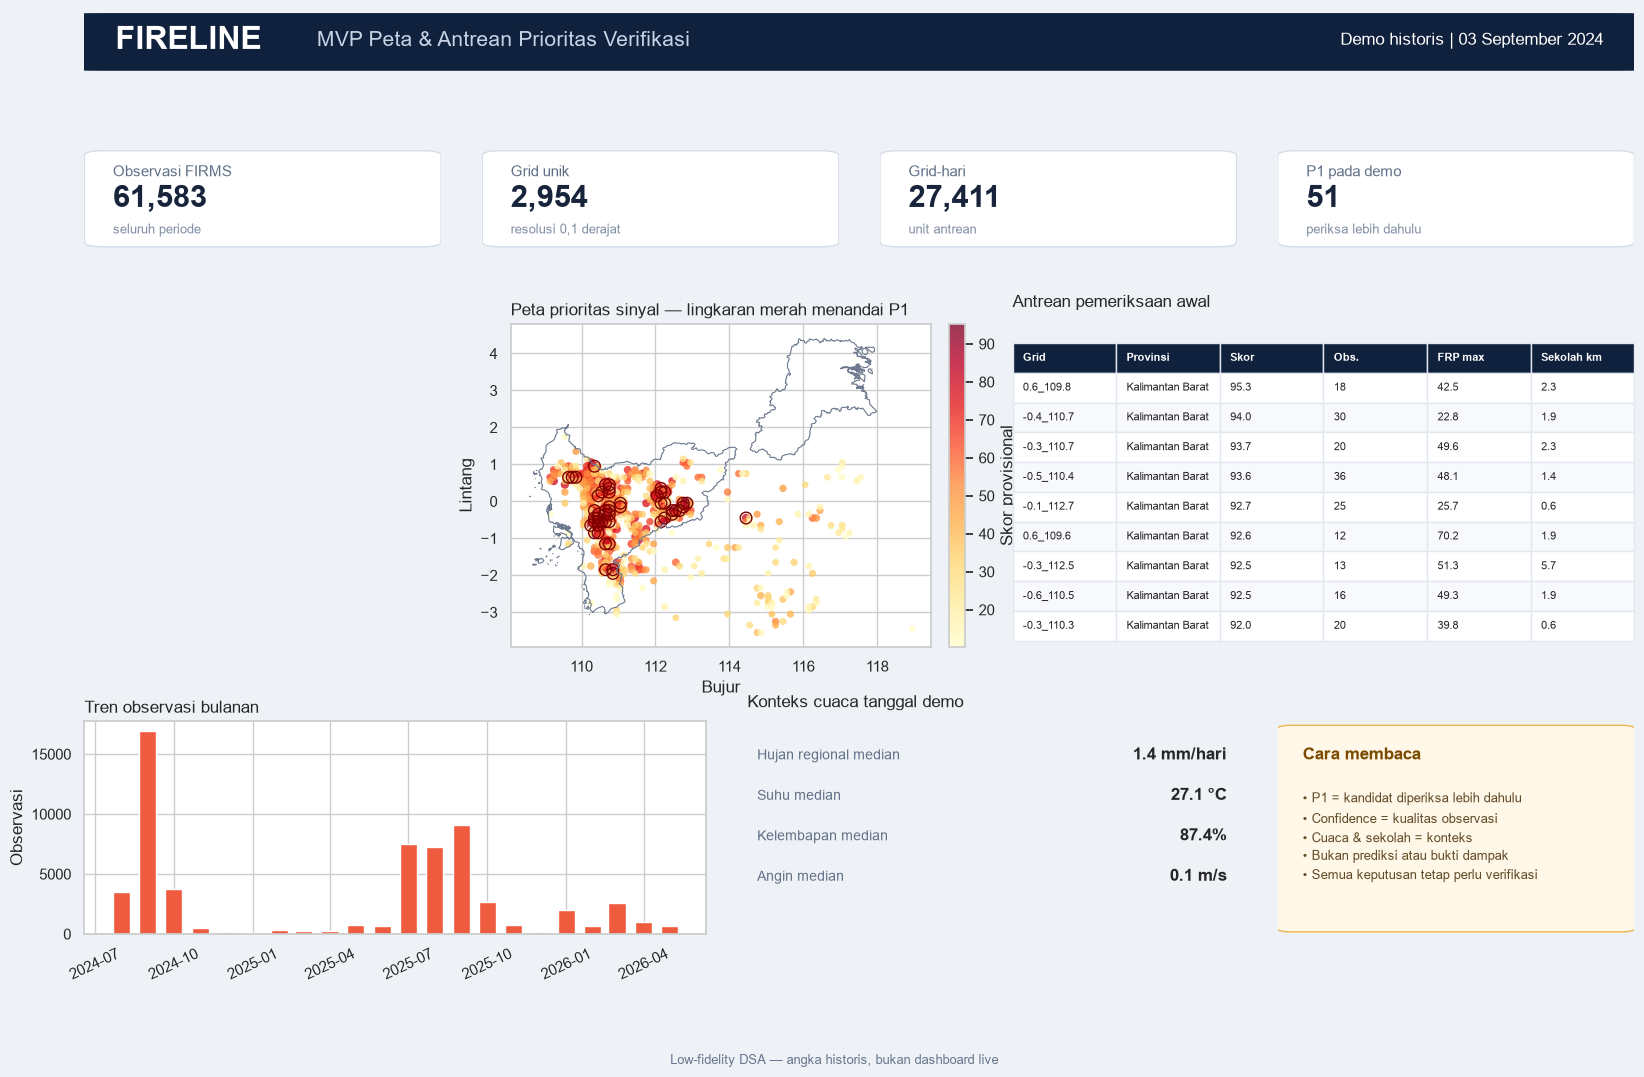

In [8]:
peak_date = firms.groupby("date").size().idxmax()
demo = grid_date[grid_date["date"].eq(peak_date)].copy()
demo = demo.sort_values(
    ["priority_score", "detection_count", "frp_max_mw"], ascending=False
)
p1_demo = demo[demo["priority_level"].eq("P1 - Periksa lebih dahulu")]

fig = plt.figure(figsize=(20, 12), facecolor="#eef2f7")
gs = GridSpec(
    4, 12, figure=fig, height_ratios=[0.75, 1.2, 3.8, 2.5],
    hspace=0.42, wspace=0.45
)

ax_header = fig.add_subplot(gs[0, :])
ax_header.axis("off")
ax_header.add_patch(
    patches.FancyBboxPatch(
        (0, 0.06), 1, 0.88,
        boxstyle="round,pad=0.012,rounding_size=0.025",
        transform=ax_header.transAxes,
        facecolor="#10213d",
        edgecolor="none",
    )
)
ax_header.text(
    0.02, 0.52, "FIRELINE",
    color="white", fontsize=23, fontweight="bold", va="center"
)
ax_header.text(
    0.15, 0.52, "MVP Peta & Antrean Prioritas Verifikasi",
    color="#c7d2e5", fontsize=15, va="center"
)
ax_header.text(
    0.98, 0.52, f"Demo historis | {peak_date:%d %B %Y}",
    color="white", fontsize=12, ha="right", va="center"
)

kpis = [
    ("Observasi FIRMS", f"{len(firms):,}", "seluruh periode"),
    ("Grid unik", f"{grid_date['grid_id'].nunique():,}", "resolusi 0,1 derajat"),
    ("Grid-hari", f"{len(grid_date):,}", "unit antrean"),
    ("P1 pada demo", f"{len(p1_demo):,}", "periksa lebih dahulu"),
]
for index, (label, value, note) in enumerate(kpis):
    ax = fig.add_subplot(gs[1, index * 3:(index + 1) * 3])
    ax.axis("off")
    ax.add_patch(
        patches.FancyBboxPatch(
            (0.02, 0.05), 0.96, 0.9,
            boxstyle="round,pad=0.02,rounding_size=0.05",
            transform=ax.transAxes,
            facecolor="white",
            edgecolor="#d5ddea",
        )
    )
    ax.text(0.08, 0.72, label, fontsize=11, color="#5f6f86")
    ax.text(0.08, 0.42, value, fontsize=22, fontweight="bold", color="#17243b")
    ax.text(0.08, 0.16, note, fontsize=9, color="#8190a5")

ax_map = fig.add_subplot(gs[2, :7])
boundaries.boundary.plot(ax=ax_map, color="#6b778d", linewidth=0.8)
scatter = ax_map.scatter(
    demo["grid_center_lon"],
    demo["grid_center_lat"],
    c=demo["priority_score"],
    s=18 + 6 * np.sqrt(demo["detection_count"]),
    cmap="YlOrRd",
    alpha=0.78,
    edgecolor="none",
)
ax_map.scatter(
    p1_demo["grid_center_lon"],
    p1_demo["grid_center_lat"],
    facecolors="none",
    edgecolors="#7f0000",
    s=70,
    linewidths=1,
)
ax_map.set_title("Peta prioritas sinyal — lingkaran merah menandai P1", loc="left")
ax_map.set_xlabel("Bujur")
ax_map.set_ylabel("Lintang")
fig.colorbar(scatter, ax=ax_map, fraction=0.025, pad=0.02, label="Skor provisional")

ax_queue = fig.add_subplot(gs[2, 7:])
ax_queue.axis("off")
ax_queue.set_title("Antrean pemeriksaan awal", loc="left", pad=12)
queue_columns = [
    "grid_id", "province_name", "priority_score",
    "detection_count", "frp_max_mw", "nearest_school_distance_km"
]
queue = demo[queue_columns].head(9).copy()
queue["priority_score"] = queue["priority_score"].round(1)
queue["frp_max_mw"] = queue["frp_max_mw"].round(1)
queue["nearest_school_distance_km"] = queue[
    "nearest_school_distance_km"
].round(1)
queue.columns = ["Grid", "Provinsi", "Skor", "Obs.", "FRP max", "Sekolah km"]
table = ax_queue.table(
    cellText=queue.fillna("Data terbatas").values,
    colLabels=queue.columns,
    cellLoc="left",
    colLoc="left",
    bbox=[0, 0.02, 1, 0.92],
)
table.auto_set_font_size(False)
table.set_fontsize(8)
for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("#e3e8f0")
    if row == 0:
        cell.set_facecolor("#10213d")
        cell.set_text_props(color="white", fontweight="bold")
    else:
        cell.set_facecolor("white" if row % 2 else "#f7f9fc")

ax_trend = fig.add_subplot(gs[3, :5])
monthly = (
    firms.set_index("date")
    .resample("MS")
    .size()
    .rename("detection_count")
)
ax_trend.bar(monthly.index, monthly.values, width=20, color="#ef5b3f")
ax_trend.set_title("Tren observasi bulanan", loc="left")
ax_trend.set_ylabel("Observasi")
ax_trend.tick_params(axis="x", rotation=25)

ax_context = fig.add_subplot(gs[3, 5:9])
ax_context.axis("off")
weather_demo = demo[["PRECTOTCORR", "T2M", "RH2M", "WS2M"]].median()
context_lines = [
    ("Hujan regional median", f"{weather_demo['PRECTOTCORR']:.1f} mm/hari"),
    ("Suhu median", f"{weather_demo['T2M']:.1f} °C"),
    ("Kelembapan median", f"{weather_demo['RH2M']:.1f}%"),
    ("Angin median", f"{weather_demo['WS2M']:.1f} m/s"),
]
ax_context.set_title("Konteks cuaca tanggal demo", loc="left", pad=10)
for index, (label, value) in enumerate(context_lines):
    y = 0.82 - index * 0.19
    ax_context.text(0.02, y, label, fontsize=10, color="#627087")
    ax_context.text(0.98, y, value, fontsize=12, fontweight="bold", ha="right")

ax_guardrail = fig.add_subplot(gs[3, 9:])
ax_guardrail.axis("off")
ax_guardrail.add_patch(
    patches.FancyBboxPatch(
        (0.01, 0.03), 0.98, 0.93,
        boxstyle="round,pad=0.02,rounding_size=0.04",
        transform=ax_guardrail.transAxes,
        facecolor="#fff7e7",
        edgecolor="#f0b44d",
    )
)
ax_guardrail.text(
    0.07, 0.82, "Cara membaca", fontsize=12,
    fontweight="bold", color="#7b4b00"
)
ax_guardrail.text(
    0.07, 0.68,
    "• P1 = kandidat diperiksa lebih dahulu\n"
    "• Confidence = kualitas observasi\n"
    "• Cuaca & sekolah = konteks\n"
    "• Bukan prediksi atau bukti dampak\n"
    "• Semua keputusan tetap perlu verifikasi",
    fontsize=9.5, color="#624c28", va="top", linespacing=1.55
)

fig.suptitle(
    "Low-fidelity DSA — angka historis, bukan dashboard live",
    y=0.01, fontsize=9, color="#68778e"
)
plt.savefig(
    OUTPUT_DIR / "lowfi_mvp_priority_dashboard.png",
    dpi=170, bbox_inches="tight", facecolor=fig.get_facecolor()
)
plt.show()

## 8. Ekspor untuk PMA, UX, dan SEA

CSV adalah hasil lokal dan tidak disiapkan untuk Git. File JSON dan Markdown
mendokumentasikan struktur data dan metode supaya peran lain tidak harus membaca kode.

In [9]:
export_columns = [
    "grid_id", "date", "grid_center_lat", "grid_center_lon",
    "province_code", "province_name",
    "detection_count", "detections_7d", "active_days_7d",
    "frp_median_mw", "frp_max_mw",
    "high_conf_share", "low_conf_share", "nominal_or_high_share", "night_share",
    "priority_score", "priority_percentile_daily", "priority_level",
    "primary_reason", "quality_status",
    "nearest_school_distance_km", "nearest_school_name", "nearest_school_stage",
    "weather_distance_km", "PRECTOTCORR", "PRECTOTCORR_7d",
    "T2M", "RH2M", "WS2M",
]
grid_date[export_columns].to_csv(
    OUTPUT_DIR / "mvp_grid_date_priority.csv", index=False
)
demo[export_columns].head(100).to_csv(
    OUTPUT_DIR / "demo_priority_queue.csv", index=False
)
dataset_audit.to_csv(OUTPUT_DIR / "dataset_audit.csv", index=False)
ablation.to_csv(OUTPUT_DIR / "score_ablation.csv", index=False)

data_contract = {
    "product": "FIRELINE MVP",
    "unit": "one active grid on one date",
    "primary_key": ["grid_id", "date"],
    "score_status": "provisional heuristic; not a probability",
    "score_inputs": {
        "activity_score": 0.40,
        "persistence_score": 0.35,
        "intensity_score": 0.25,
    },
    "context_not_in_score": [
        "province_name",
        "nearest_school_distance_km",
        "PRECTOTCORR",
        "T2M",
        "RH2M",
        "WS2M",
    ],
    "priority_labels": [
        "P1 - Periksa lebih dahulu",
        "P2 - Pantau ketat",
        "P3 - Pemantauan biasa",
    ],
    "guardrails": [
        "FIRMS is a satellite thermal anomaly observation, not verified fire",
        "school proximity does not prove impact",
        "weather correlation does not prove causation",
        "human verification remains required",
    ],
    "api_status": "conceptual handoff only; deployed API out of MVP scope",
}
(OUTPUT_DIR / "data_contract.json").write_text(
    json.dumps(data_contract, indent=2, ensure_ascii=False), encoding="utf-8"
)

summary = {
    "firms_rows": int(len(firms)),
    "unique_grids": int(grid_date["grid_id"].nunique()),
    "grid_date_rows": int(len(grid_date)),
    "date_start": str(grid_date["date"].min().date()),
    "date_end": str(grid_date["date"].max().date()),
    "province_coverage_percent": float(
        100 * grid_date["province_name"].notna().mean()
    ),
    "weather_coverage_percent": float(100 * grid_date["T2M"].notna().mean()),
    "median_nearest_school_km": float(
        grid_date["nearest_school_distance_km"].median()
    ),
    "p1_rows": int(baseline_p1.sum()),
    "demo_date": str(peak_date.date()),
    "demo_p1_rows": int(len(p1_demo)),
}
(OUTPUT_DIR / "pipeline_summary.json").write_text(
    json.dumps(summary, indent=2, ensure_ascii=False), encoding="utf-8"
)
summary

{'firms_rows': 61583,
 'unique_grids': 2954,
 'grid_date_rows': 27411,
 'date_start': '2024-08-01',
 'date_end': '2026-05-31',
 'province_coverage_percent': 97.09605632775164,
 'weather_coverage_percent': 100.0,
 'median_nearest_school_km': 2.940358931660761,
 'p1_rows': 3114,
 'demo_date': '2024-09-03',
 'demo_p1_rows': 51}